In [10]:
import baltic as bt
import pandas as pd
import numpy as np
import json
import os
import matplotlib.pyplot as plt
import itertools
from collections import defaultdict
import statistics
import numpy as np
import re
import random
import math
from scipy.stats import chi2_contingency

In [15]:
tree = 'na_avian/summary_baltic.nwk'
traits_file = 'na_avian/traits.json'

flyways = ['mississippi_flyway', 'atlantic_flyway', 'central_flyway', 'pacific_flyway']

with open(traits_file) as f:
    traits = json.load(f)

mytree= bt.loadNewick(tree, absoluteTime= False)
node_traits = traits["nodes"]

flyway_total_count = {flyway:0 for flyway in flyways}

rea_count = 0

for k in mytree.Objects:
    
    name = k.traits["label"] if k.is_node() else k.name
    
    k.traits["flyway"] = node_traits[name]["flyway"]
    
    if k.is_leaf() and k.traits["flyway"] != "unknown":
        
        flyway_total_count[k.traits['flyway']] += 1
        
    if k.is_node() and k.traits["is_reassorted"] and k.traits['flyway'] != 'unknown':
        
        rea_count += 1
        

In [16]:
rea_count

305

In [17]:
total = sum(flyway_total_count.values())

print(total)

props = {k: v / total for k, v in flyway_total_count.items()}

props

1184


{'mississippi_flyway': 0.31165540540540543,
 'atlantic_flyway': 0.21537162162162163,
 'central_flyway': 0.28631756756756754,
 'pacific_flyway': 0.1866554054054054}

In [13]:
all_counts = {flyway: [] for flyway in flyways}

for i in range(1000):
    
    tree = f'na_avian/trees/randomized_tree_{i}.nwk'
    mytree= bt.loadNewick(tree, absoluteTime= False)
    
    flyway_count = {flyway:0 for flyway in flyways}
    
    for k in mytree.Objects:
        
        if k.is_node() and k.traits["is_reassorted"]:
            
            name = k.traits['label']
            
            k.traits["flyway"] = node_traits[name]["flyway"]
            
            if k.traits['flyway'] != 'unknown':
                
                flyway_count[k.traits['flyway']] += 1
                
    for flyway in flyways:
        all_counts[flyway].append(flyway_count[flyway])

In [18]:
replicate_props = {
    flyway: [count / rea_count for count in all_counts[flyway]]
    for flyway in flyways
}

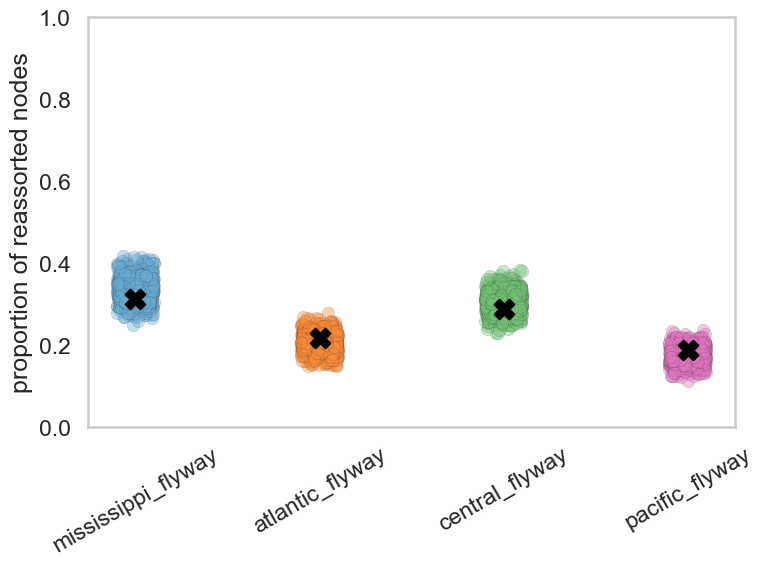

In [53]:
x_positions = np.arange(len(flyways))
plt.figure(figsize=(8,6))

jitter_strength = 0.1

colors = {
    "mississippi_flyway": "#6baed6",  # soft blue
    "atlantic_flyway": "#fd8d3c",     # soft orange
    "central_flyway": "#74c476",      # soft green
    "pacific_flyway": "#e377c2"       # soft pink
}

for i, flyway in enumerate(flyways):
    y_vals = replicate_props[flyway]
    x_vals = np.full(len(y_vals), i) + np.random.uniform(-jitter_strength, jitter_strength, size=len(y_vals))
    plt.scatter(x_vals, y_vals, alpha=0.4, color=colors[flyway], edgecolor='k', linewidth=0.2)

observed_vals = [props[flyway] for flyway in flyways]
plt.scatter(x_positions, observed_vals, marker='X', color='black', s=200, zorder=5)

plt.xticks(x_positions, flyways, rotation=30)
plt.ylabel("proportion of reassorted nodes")
plt.ylim(0, 1)

plt.grid(False)

plt.tight_layout()
plt.show()

In [51]:
p_values = {}

for flyway in flyways:
    
    replicates = replicate_props[flyway]
    
    n = len(replicates)
    
    observed = props[flyway]

    median_replicates = np.median(replicates)

    observed_dist = abs(observed - median_replicates) # computes the absolute distance of the observed value from the median of replicates
    
    replicate_dist = [abs(r - median_replicates) for r in replicates] # computes the absolute distance of each replicate from the median
    
    p = (sum(d >= observed_dist for d in replicate_dist)) / n # counts how many replicates have a distance ≥ the observed distance
    
    p_values[flyway] = 1.0 if p * 4 > 1.0 else p # bonferroni corrected

print("empirical p-values (two-sided):")
for flyway, p in p_values.items():
    print(f"{flyway}: {p:.4f}")

empirical p-values (two-sided):
mississippi_flyway: 1.0000
atlantic_flyway: 1.0000
central_flyway: 1.0000
pacific_flyway: 1.0000
